# UX Research Documentation Survey Analysis

This notebook analyzes the LimeSurvey export `results-survey.xlsx` and exports every figure as a separate **PDF**. 

The notebook:

- loads and cleans the Excel export,
- handles LimeSurvey question-code prefixes such as `B2A1[...]`,
- supports partial responses with item-level denominators,
- creates publication-oriented Matplotlib figures using a serif font,It is tailored to the survey on UX/user-research documentation practices and AI support, but it is also designed to remain robust when more responses are added in the same export format. preferably **Linux Libertine**, with Times-like fallbacks,
- exports all figures to `survey_analysis_outputs_english/figures_pdf/`,
- exports the underlying frequency tables to `survey_analysis_outputs_english/tables_csv/`,
- exports open-text answers in long format for qualitative analysis.

By default, partial responses are included. Change `USE_ONLY_SUBMITTED_RESPONSES` below if you only want fully submitted responses.

## 1. Setup

Place the Excel file in the same folder as this notebook, or adjust `DATA_PATH` below.

```bash
pip install pandas openpyxl matplotlib numpy jupyter
```

In [1]:
from pathlib import Path
import re
import textwrap
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

try:
    from IPython.display import display
except Exception:
    display = None

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
DATA_PATH = Path("results-survey.xlsx")
if not DATA_PATH.exists():
    fallback = Path("/mnt/data/results-survey.xlsx")
    if fallback.exists():
        DATA_PATH = fallback

SHEET_NAME = 0
OUT_DIR = Path("survey_analysis_outputs_english")
FIG_DIR = OUT_DIR / "figures_pdf"
TABLE_DIR = OUT_DIR / "tables_csv"

# Remove stale exports so the output folder does not contain older figures.
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# When True, substantive analyses use only rows with a submitted/completed timestamp.
# For early survey results it is often useful to keep partial answers and use item-level denominators.
USE_ONLY_SUBMITTED_RESPONSES = False

# Set True if you also want PNGs in addition to PDFs.
EXPORT_PNG = False

# Display figures inline when running in a notebook.
DISPLAY_FIGURES = True

# ---------------------------------------------------------------------
# Typography / plot style
# ---------------------------------------------------------------------
FONT_CANDIDATES = [
    "Linux Libertine O",
    "Libertinus Serif",
    "Times New Roman",
    "Tinos",
    "Nimbus Roman",
    "Liberation Serif",
    "DejaVu Serif",
]

def choose_font(candidates=FONT_CANDIDATES):
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    return "DejaVu Serif"

PLOT_FONT = choose_font()
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": FONT_CANDIDATES,
    "pdf.fonttype": 42,      # editable text in vector PDFs where possible
    "ps.fonttype": 42,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
})

print(f"Using data file: {DATA_PATH}")
print(f"Using plot font: {PLOT_FONT}")
print(f"PDF export folder: {FIG_DIR.resolve()}")

Using data file: results-survey.xlsx
Using plot font: Linux Libertine O
PDF export folder: /home/sabine/Projects/Obsidian4UX/survey_analysis_outputs_english/figures_pdf


In [2]:
def clean_column_name(c):
    """Normalize spaces, including non-breaking spaces from Excel LimeSurvey exports."""
    return re.sub(r"\s+", " ", str(c).replace("\xa0", " ")).strip()

def clean_frame(data):
    out = data.copy()
    out.columns = [clean_column_name(c) for c in out.columns]

    # Normalize object columns; keep actual NaN values.
    for col in out.select_dtypes(include="object").columns:
        out[col] = out[col].map(lambda x: re.sub(r"\s+", " ", str(x)).strip() if pd.notna(x) else np.nan)
        out[col] = out[col].replace({"": np.nan, "N/A": np.nan, "n/a": np.nan, "NA": np.nan})

    # Parse LimeSurvey date columns. The updated export uses names such as "submitdate. Date submitted".
    for col in out.columns:
        low = col.lower()
        if any(token in low for token in ["date submitted", "date started", "date last action", "submitdate", "startdate", "datestamp"]):
            out[col] = pd.to_datetime(out[col], errors="coerce")
    return out

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
df = clean_frame(df_raw)

print(f"Data shape: {df.shape[0]} rows × {df.shape[1]} columns")

Data shape: 22 rows × 356 columns


/tmp/ipykernel_9265/21922952.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in out.select_dtypes(include="object").columns:


## 2. Helper functions

These helpers handle common LimeSurvey export patterns: question-code prefixes, single-choice questions, multi-select columns, matrix/Likert blocks, optional comments, and long labels.

In [3]:
def norm(s):
    return re.sub(r"\s+", " ", str(s).replace("\xa0", " ")).strip().lower()

def strip_code_prefix(col):
    """Remove a LimeSurvey code prefix such as 'B2A1[SQ002]. ' from a column label."""
    return re.sub(r"^[A-Za-z0-9]+(?:\[[^\]]+\])?\.\s*", "", str(col)).strip()

def column_code(col):
    """Return the LimeSurvey question code before '.', ignoring subquestion brackets."""
    m = re.match(r"^([A-Za-z0-9]+)(?:\[[^\]]+\])?\.", str(col))
    return m.group(1) if m else None

def is_comment_col(col):
    """Return True for LimeSurvey side columns that hold comments, not for questions that merely mention a comment box."""
    col = str(col)
    prefix = col.split(".", 1)[0].lower()
    text = strip_code_prefix(col).lower()
    has_comment_in_code = bool(re.search(r"\[[^\]]*comment[^\]]*\]", prefix))
    has_comment_answer_label = bool(re.search(r"\[(?:comment|other comment)\]\s*$", text))
    return has_comment_in_code or has_comment_answer_label

def is_other_text_col(col):
    return bool(re.match(r"^[A-Za-z0-9]+\[other\]\. ", str(col), flags=re.IGNORECASE))

def code_cols(code, include_comments=False):
    """All columns whose LimeSurvey question code equals `code`."""
    cols = [c for c in df.columns if column_code(c) == code]
    if not include_comments:
        cols = [c for c in cols if not is_comment_col(c)]
    return cols

def code_cols_many(codes, include_comments=False):
    cols = []
    for code in codes:
        cols.extend(code_cols(code, include_comments=include_comments))
    return cols

def single_col_by_code(code):
    """Return the main single-answer column for a code, excluding [other] and [comment] side columns."""
    exact = [c for c in df.columns if re.match(rf"^{re.escape(code)}\.\s", str(c))]
    exact = [c for c in exact if not is_comment_col(c)]
    if exact:
        return exact[0]
    non_side = [c for c in code_cols(code) if "[" not in str(c).split(".", 1)[0]]
    return non_side[0] if non_side else None

def first_col_contains(fragment, columns=None):
    cols = list(df.columns if columns is None else columns)
    matches = [c for c in cols if norm(fragment) in norm(strip_code_prefix(c))]
    if not matches:
        warnings.warn(f"No column found for fragment: {fragment}")
        return None
    return matches[0]

def cols_containing(fragment, columns=None, include_comments=False):
    cols = list(df.columns if columns is None else columns)
    out = [c for c in cols if norm(fragment) in norm(strip_code_prefix(c))]
    if not include_comments:
        out = [c for c in out if not is_comment_col(c)]
    return out

def option_label(col):
    """Return the final bracketed option label from a LimeSurvey column, ignoring code brackets."""
    text = strip_code_prefix(col)
    parts = re.findall(r"\[([^\]]+)\]", text)
    parts = [p for p in parts if p.lower() != "comment"]
    if parts:
        return parts[-1].strip()
    return text.strip()

def question_label(col):
    """Return the question stem without bracketed answer options."""
    text = strip_code_prefix(col)
    return re.sub(r"\s*\[[^\]]+\]", "", text).strip()

def category_label(col):
    """Return a group/category label for matrix-style columns such as 'Office tools: [Word]'."""
    text = strip_code_prefix(col)
    base = re.sub(r"\s*\[[^\]]+\].*", "", text).strip()
    return base.rstrip(":").strip()

def option_label_with_group(col):
    group = category_label(col)
    opt = option_label(col)
    return f"{group}: {opt}" if group and group != opt else opt

def shorten(s, width=48):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def make_safe_filename(s):
    s = norm(s)
    s = re.sub(r"[^a-z0-9_-]+", "_", s)
    return s.strip("_")[:100]

def save_and_show(fig, filename):
    filename = make_safe_filename(filename)
    pdf_path = FIG_DIR / f"{filename}.pdf"
    fig.savefig(pdf_path, format="pdf")
    if EXPORT_PNG:
        fig.savefig(FIG_DIR / f"{filename}.png")
    if DISPLAY_FIGURES and display is not None:
        display(fig)
    plt.close(fig)
    return pdf_path

def style_axis(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.25)
        ax.set_axisbelow(True)
    return ax

def selected_mask(series):
    """Detect selected entries in yes/no multi-select columns; free-text non-empty values count as selected."""
    text = series.astype("string").str.strip().str.lower()
    falsey = {"no", "nein", "not selected", "false", "0", "nan", "none", "", "not applicable", "n/a", "na"}
    return series.notna() & (~text.isin(falsey))

def reached_n(data, columns):
    """Number of rows that appear to have reached a question block."""
    columns = [c for c in columns if c in data.columns]
    if not columns:
        return 0
    return int(data[columns].notna().any(axis=1).sum())

In [4]:
# Identify analysis rows.
eligible_col = single_col_by_code("A1") or first_col_contains("currently work with user research")
if eligible_col is not None:
    analysis_df = df[df[eligible_col].eq("Yes")].copy()
else:
    analysis_df = df.copy()

submitted_col = first_col_contains("Date submitted")
if USE_ONLY_SUBMITTED_RESPONSES and submitted_col is not None:
    analysis_df = analysis_df[analysis_df[submitted_col].notna()].copy()

summary_rows = [{"metric": "Raw started responses", "n": len(df)}]
if submitted_col is not None:
    summary_rows.append({"metric": "Submitted / complete responses", "n": int(df[submitted_col].notna().sum())})
if eligible_col is not None:
    summary_rows.append({"metric": "Eligible UX / user research responses", "n": int(df[eligible_col].eq("Yes").sum())})
summary_rows.append({"metric": "Rows used for substantive plots", "n": len(analysis_df)})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(TABLE_DIR / "00_sample_summary.csv", index=False)
display(summary_df) if display else print(summary_df)

,metric,n
0,Raw started responses,22
1,Submitted / complete responses,7
2,Eligible UX / user research responses,17
3,Rows used for substantive plots,17


## 3. Plot functions

All plot functions save a PDF automatically and export the aggregated data as CSV.

In [5]:
import textwrap


def apply_large_plot_style():
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": 14,
        "axes.labelsize": 13.5,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def wrap_label(text, width=42, max_lines=3):
    text = str(text)

    lines = textwrap.wrap(
        text,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )

    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip(" .,:;") + "…"

    return "\n".join(lines)


def plot_height_from_labels(labels, min_height=3.2, base=1.3, per_line=0.31):
    visual_lines = sum(label.count("\n") + 1 for label in labels)
    return max(min_height, base + per_line * visual_lines)


def style_horizontal_bar_axis(ax):
    ax.grid(axis="x", color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#999999")
    ax.tick_params(axis="x", labelsize=12.5)
    ax.tick_params(axis="y", labelsize=13)


def plot_single_choice(
    data,
    column,
    title=None,
    filename=None,
    order=None,
    max_items=None,
    min_count=0,
):
    apply_large_plot_style()

    if column is None or column not in data:
        print(f"Skipped single-choice plot because no valid column was found: {title}")
        return None

    s = data[column].dropna()

    if s.empty:
        print(f"No data for {column}")
        return None

    counts = s.value_counts()

    if order:
        ordered = [x for x in order if x in counts.index] + [
            x for x in counts.index if x not in order
        ]
        counts = counts.loc[ordered]

    counts = counts[counts >= min_count]

    if max_items:
        counts = counts.head(max_items)

    if counts.empty:
        print(f"No data above min_count for {title or column}")
        return None

    counts = counts.sort_values(ascending=True)
    n = int(s.shape[0])

    labels = [wrap_label(x, width=42, max_lines=3) for x in counts.index]

    height = plot_height_from_labels(
        labels,
        min_height=3.2,
        base=1.25,
        per_line=0.31,
    )

    fig, ax = plt.subplots(figsize=(8.0, height))

    y = np.arange(len(counts))

    ax.barh(
        y,
        counts.values,
        color="#005383",
        edgecolor="white",
        linewidth=0.8,
        height=0.54,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=13, linespacing=1.05)

    ax.set_xlabel("Number of responses", fontsize=13, labelpad=8)
    #ax.set_title(
    #    (title or question_label(column)) + f" (n={n})",
    #    fontsize=14,
    #    pad=9,
    #)

    x_max = max(counts.max(), 1)
    ax.set_xlim(0, x_max * 1.25)

    for y_pos, v in enumerate(counts.values):
        ax.text(
            v + x_max * 0.025,
            y_pos,
            f"{int(v)} / {v / n:.0%}",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#333333",
        )

    style_horizontal_bar_axis(ax)

    fig.subplots_adjust(
        left=0.40,
        right=0.96,
        top=0.86,
        bottom=0.18,
    )

    counts.rename("count").to_csv(
        TABLE_DIR / f"{make_safe_filename(filename or title or column)}.csv"
    )

    return save_and_show(fig, filename or title or column)


def multiselect_counts(data, columns, label_func=option_label):
    rows = []
    columns = [c for c in columns if c in data.columns and not is_comment_col(c)]
    denom = reached_n(data, columns)

    for c in columns:
        count = int(selected_mask(data[c]).sum())

        rows.append({
            "item": label_func(c),
            "column": c,
            "count": count,
            "percent": count / denom * 100 if denom else np.nan,
        })

    table = pd.DataFrame(rows)

    if table.empty:
        return pd.DataFrame(columns=["item", "column", "count", "percent"]), denom

    return table.sort_values(["count", "item"], ascending=[False, True]), denom


def plot_multiselect(
    data,
    columns,
    title=None,
    filename=None,
    top_n=None,
    min_count=0,
    label_func=option_label,
):
    apply_large_plot_style()

    columns = [c for c in list(columns) if c in data.columns and not is_comment_col(c)]

    if not columns:
        print(f"No columns found for {title}")
        return None

    table, denom = multiselect_counts(data, columns, label_func=label_func)
    table = table[table["count"] >= min_count]

    if top_n:
        table = table.head(top_n)

    table = table.sort_values("count", ascending=True)

    table.to_csv(
        TABLE_DIR / f"{make_safe_filename(filename or title or 'multiselect')}.csv",
        index=False,
    )

    if table.empty or denom == 0 or table["count"].max() == 0:
        print(f"No selected answers for {title}")
        return None

    labels = [wrap_label(x, width=44, max_lines=3) for x in table["item"]]

    height = plot_height_from_labels(
        labels,
        min_height=3.4,
        base=1.35,
        per_line=0.31,
    )

    fig, ax = plt.subplots(figsize=(8.4, height))

    y = np.arange(len(table))

    ax.barh(
        y,
        table["count"],
        color="#0087bb",
        edgecolor="white",
        linewidth=0.8,
        height=0.54,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=13, linespacing=1.05)

    ax.set_xlabel("Selections", fontsize=13, labelpad=8)
    #ax.set_title(
    #    title,#(title or "Multiple selection") + f" (n={denom}; multiple answers possible)",
    #    fontsize=14,
    #    pad=9,
    #)

    x_max = max(table["count"].max(), 1)
    ax.set_xlim(0, x_max * 1.25)

    for y_pos, (_, row) in enumerate(table.iterrows()):
        ax.text(
            row["count"] + x_max * 0.025,
            y_pos,
            f"{int(row['count'])} / {row['percent']:.0f}%",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#333333",
        )

    style_horizontal_bar_axis(ax)

    fig.subplots_adjust(
        left=0.42,
        right=0.96,
        top=0.86,
        bottom=0.18,
    )

    return save_and_show(fig, filename or title or "multiselect")


def plot_multiselect_categories(data, code_to_label, title, filename, min_count=0):
    apply_large_plot_style()

    all_cols = []

    for code in code_to_label:
        all_cols.extend(code_cols(code))

    all_cols = [c for c in all_cols if c in data.columns and not is_comment_col(c)]
    denom = reached_n(data, all_cols)

    rows = []

    for code, label in code_to_label.items():
        pcols = [
            c for c in code_cols(code)
            if c in data.columns and not is_comment_col(c)
        ]

        if not pcols:
            continue

        any_selected = pd.DataFrame({
            c: selected_mask(data[c])
            for c in pcols
        }).any(axis=1)

        count = int(any_selected.sum())

        rows.append({
            "category": label,
            "count": count,
            "percent": count / denom * 100 if denom else np.nan,
        })

    table = pd.DataFrame(rows)

    if table.empty:
        table = pd.DataFrame(columns=["category", "count", "percent"])
        table.to_csv(TABLE_DIR / f"{make_safe_filename(filename)}.csv", index=False)
        print(f"No category columns found for {title}")
        return None

    table = table[table["count"] >= min_count]
    table = table.sort_values("count", ascending=True)

    table.to_csv(TABLE_DIR / f"{make_safe_filename(filename)}.csv", index=False)

    if table.empty or denom == 0 or table["count"].max() == 0:
        print(f"No category selections for {title}")
        return None

    labels = [wrap_label(x, width=42, max_lines=3) for x in table["category"]]

    height = plot_height_from_labels(
        labels,
        min_height=3.2,
        base=1.25,
        per_line=0.31,
    )

    fig, ax = plt.subplots(figsize=(8.0, height))

    y = np.arange(len(table))

    ax.barh(
        y,
        table["count"],
        color="#5c6f7e",
        edgecolor="white",
        linewidth=0.8,
        height=0.54,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=13, linespacing=1.05)

    ax.set_xlabel(
        "Respondents with at least one selection",
        fontsize=13,
        labelpad=8,
    )
    #ax.set_title(
    #    f"{title} (n={denom}; multiple answers possible)",
    #    fontsize=14,
    #    pad=9,
    #)

    x_max = max(table["count"].max(), 1)
    ax.set_xlim(0, x_max * 1.25)

    for y_pos, (_, row) in enumerate(table.iterrows()):
        ax.text(
            row["count"] + x_max * 0.025,
            y_pos,
            f"{int(row['count'])} / {row['percent']:.0f}%",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#333333",
        )

    style_horizontal_bar_axis(ax)

    fig.subplots_adjust(
        left=0.42,
        right=0.96,
        top=0.86,
        bottom=0.18,
    )

    return save_and_show(fig, filename)

def plot_likert(
    data,
    columns,
    order,
    title,
    filename,
    label_func=option_label,
    sort_by_mean=True,
):
    apply_large_plot_style()

    columns = [c for c in columns if c in data.columns and not is_comment_col(c)]
    rows, means = [], []
    score_map = {v: i + 1 for i, v in enumerate(order)}

    for c in columns:
        s = data[c].dropna()
        if s.empty:
            continue

        counts = s.value_counts().reindex(order, fill_value=0)
        total = int(counts.sum())
        if total == 0:
            continue

        pct = counts / total * 100
        rows.append({"label": label_func(c), "n": total, **pct.to_dict()})
        means.append(pd.to_numeric(s.map(score_map), errors="coerce").mean())

    if not rows:
        print(f"No data for {title}")
        return None

    table = pd.DataFrame(rows)
    table["mean_score"] = means

    if sort_by_mean:
        table = table.sort_values("mean_score", ascending=True)

    table.to_csv(TABLE_DIR / f"{make_safe_filename(filename)}.csv", index=False)

    labels = [
        wrap_label(f"{r['label']} (n={int(r['n'])})", width=62, max_lines=2)
        for _, r in table.iterrows()
    ]

    y = np.arange(len(table))

    # Height of the actual plot area
    main_height = max(4.2, 0.46 * len(table) + 1.4)

    # Put the legend in its own row.
    # This is much more robust than tuning bottom_frac.
    legend_ncol = len(order)
    legend_rows = 1
    legend_height = 0.42

    fig_height = main_height + legend_height
    
    fig = plt.figure(figsize=(12, fig_height))
    
    gs = fig.add_gridspec(
        nrows=2,
        ncols=1,
        height_ratios=[main_height, legend_height],
        hspace=0.18,
    )

    ax = fig.add_subplot(gs[0])
    legend_ax = fig.add_subplot(gs[1])
    legend_ax.axis("off")

    if len(order) == 5:
        colors = ["#aa0503", "#df3d26", "#5c6f7e", "#0087bb", "#005383"]
    else:
        cmap = plt.get_cmap("viridis")
        colors = [cmap(i / max(len(order) - 1, 1)) for i in range(len(order))]

    left = np.zeros(len(table))

    for response, color in zip(order, colors):
        vals = table[response].to_numpy(dtype=float)

        ax.barh(
            y,
            vals,
            left=left,
            label=response,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            height=0.64,
        )

        for i, v in enumerate(vals):
            if v >= 4:
                ax.text(
                    left[i] + v / 2,
                    y[i],
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=11.5,
                    color="white",
                    fontweight="bold",
                )

        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=15, linespacing=1.05)
    ax.tick_params(axis="x", labelsize=15)
    ax.set_xlim(0, 100)

    ax.set_xlabel(
        "Share of responses per item (%)",
        fontsize=15,
        labelpad=8,
    )
    ax.set_title(title, fontsize=14, pad=10)

    ax.grid(axis="x", color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#999999")

    handles, legend_labels = ax.get_legend_handles_labels()

    legend_ax.legend(
        handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.65),
        ncol=legend_ncol,
        frameon=False,
        fontsize=15,
        handlelength=1.2,
        columnspacing=1.4,
        handletextpad=0.6,
    )
    fig.subplots_adjust(
        left=0.34,
        right=0.98,
        top=0.93,
        bottom=0.04,
    )

    return save_and_show(fig, filename)

## 4. Response status and sample profile

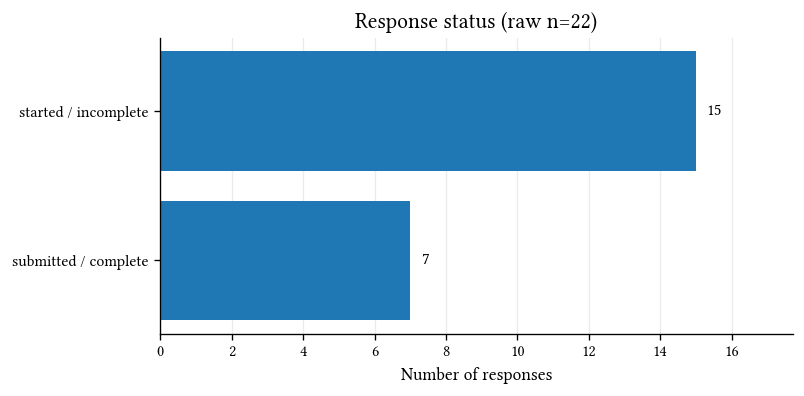

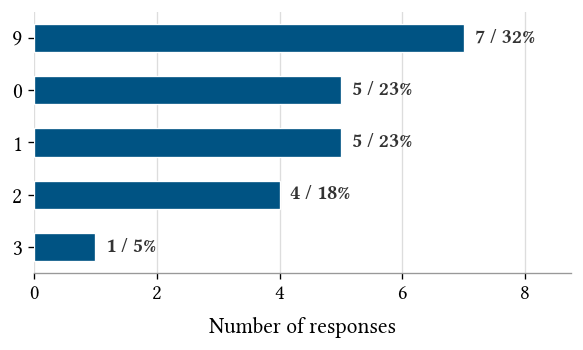

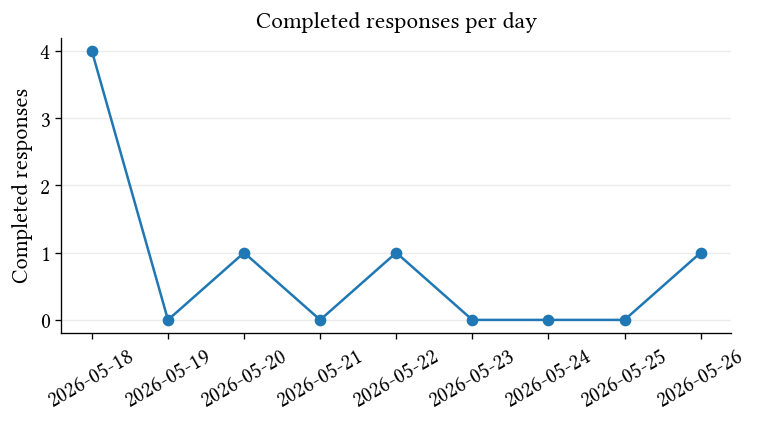

In [6]:
# Response status: started vs. submitted
if submitted_col is not None:
    submitted = df[submitted_col].notna()
    status = pd.Series(np.where(submitted, "submitted / complete", "started / incomplete"), name="Status")
    status_counts = status.value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(6.8, 3.2))
    ax.barh(status_counts.index, status_counts.values)
    ax.set_xlabel("Number of responses")
    ax.set_title(f"Response status (raw n={len(df)})")
    x_max = max(status_counts.max(), 1)
    ax.set_xlim(0, x_max * 1.18)
    for y, v in enumerate(status_counts.values):
        ax.text(v + x_max * 0.02, y, str(int(v)), va="center")
    style_axis(ax)
    save_and_show(fig, "01_response_status")
    
# Last page reached in questionnaire
last_page_col = first_col_contains("Last page")
plot_single_choice(df, last_page_col, "Last page reached in the questionnaire", "02_last_page_raw")

# Submissions per day
if submitted_col is not None and df[submitted_col].notna().any():
    daily = df.dropna(subset=[submitted_col]).set_index(submitted_col).resample("D").size()
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.plot(daily.index, daily.values, marker="o")
    ax.set_ylabel("Completed responses")
    ax.set_title("Completed responses per day")
    ax.tick_params(axis="x", rotation=30)
    style_axis(ax, grid_axis="y")
    save_and_show(fig, "02b_completed_responses_per_day")

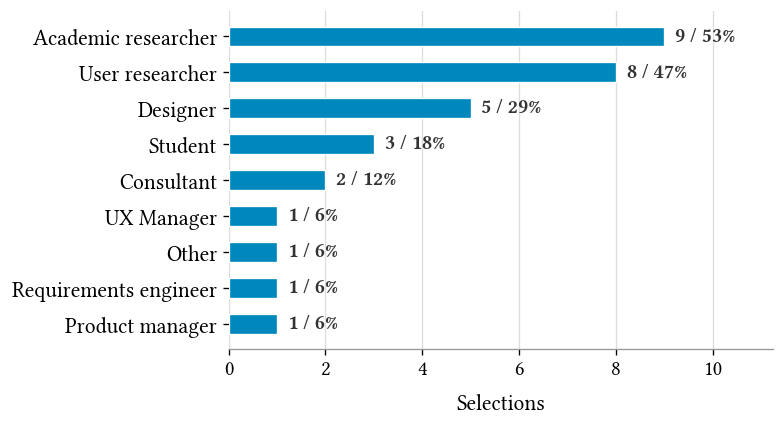

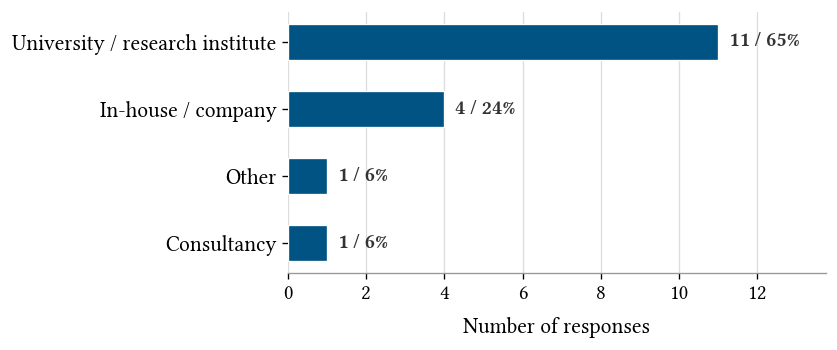

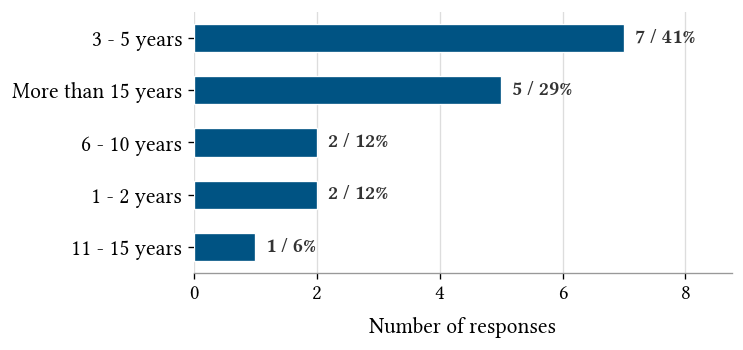

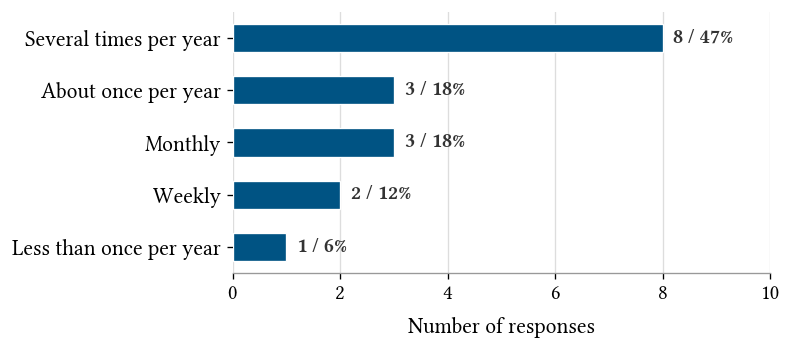

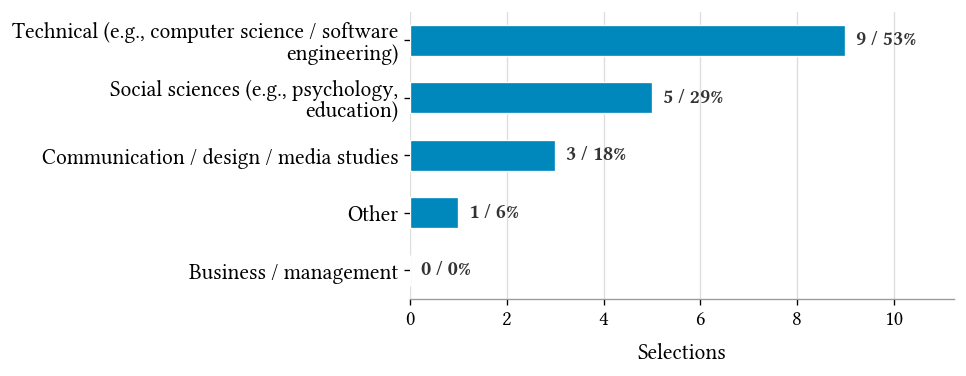

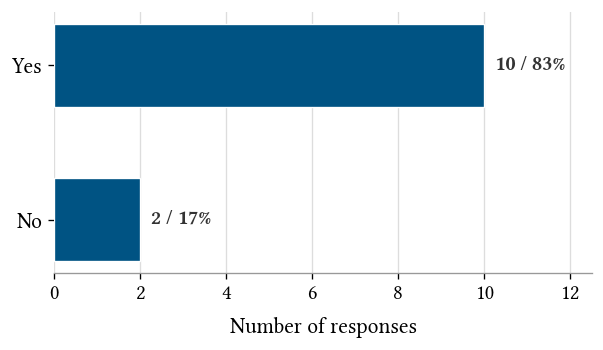

PosixPath('survey_analysis_outputs_english/figures_pdf/07b_documentation_required.pdf')

In [7]:
plot_multiselect(
    analysis_df,
    code_cols("A2"),
    None, #"Respondent roles",
    "03_roles",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("A3"),
    None, #"Organization type",
    "04_organization_type",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("A4"),
    None, #"UX / research experience",
    "05_experience",
    order=["Less than 1 year", "1 - 2 years", "3 - 5 years", "6 - 10 years", "11 - 15 years", "More than 15 years"],
)

plot_single_choice(
    analysis_df,
    single_col_by_code("A5"),
    None, #"Frequency of UX research work",
    "06_research_frequency",
    order=["Less than once per year", "About once per year", "Several times per year", "Monthly", "Weekly", "Daily or almost daily"],
)

plot_multiselect(
    analysis_df,
    code_cols("A9"),
    None, #"Disciplinary or educational background",
    "07_background",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("A7"),
    None, #"Is documentation required in the respondent's domain?",
    "07b_documentation_required",
)

## 5. Current documentation practices

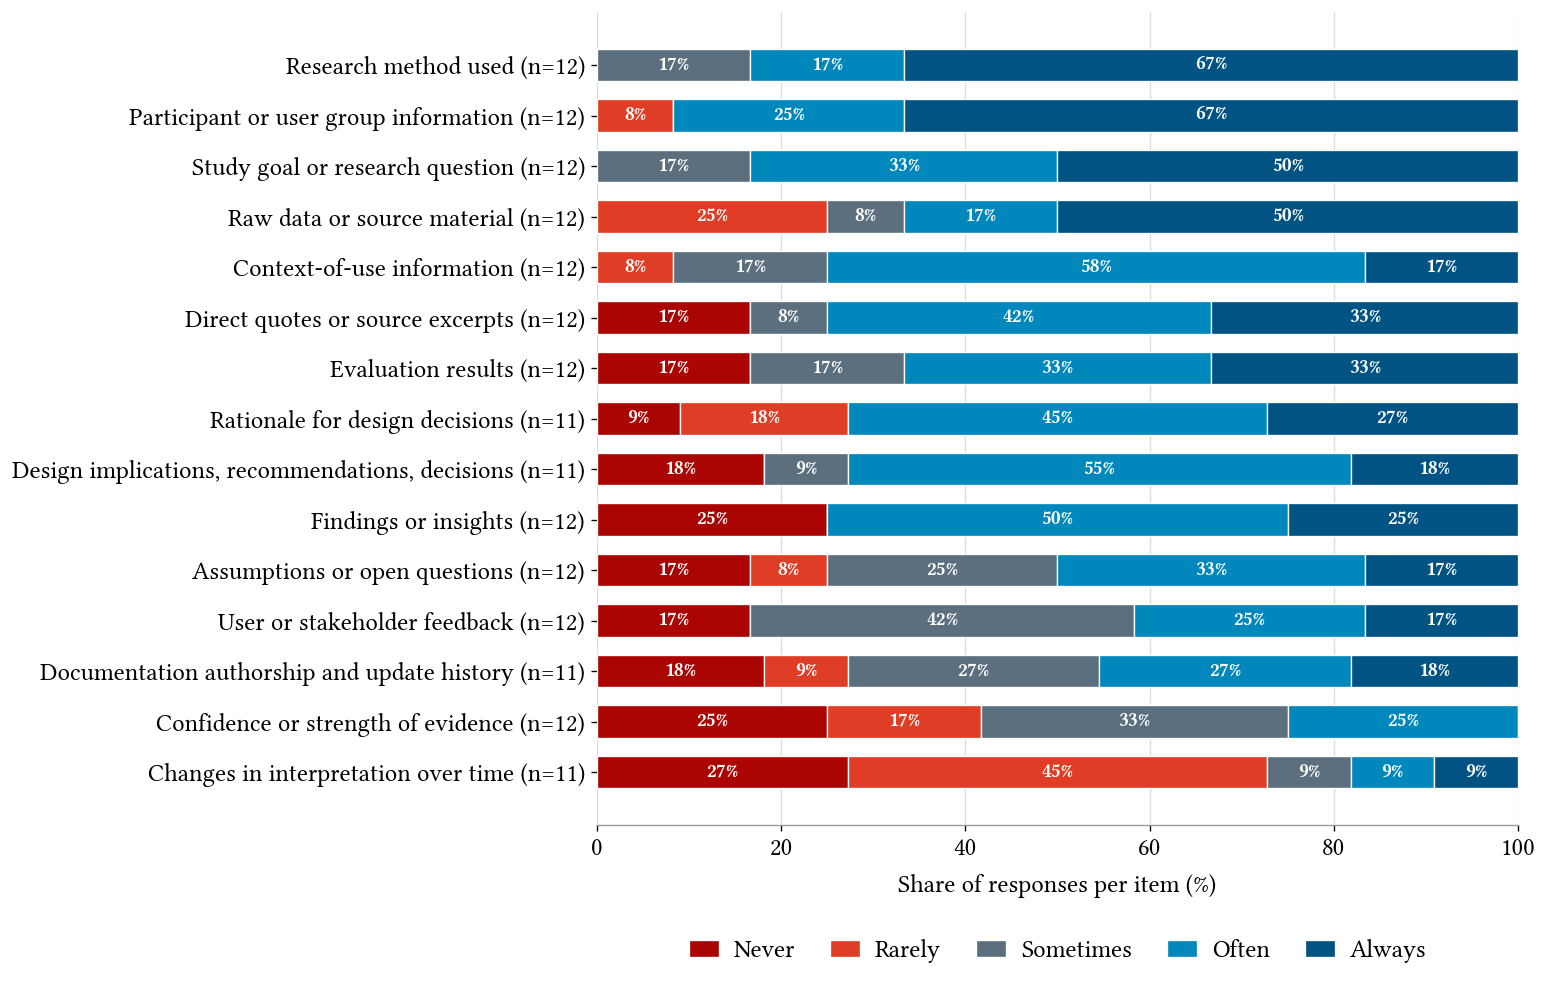

PosixPath('survey_analysis_outputs_english/figures_pdf/08_documentation_content_frequency.pdf')

In [8]:
frequency_order = ["Never", "Rarely", "Sometimes", "Often", "Always"]
info_cols = code_cols_many(["B5A1", "B5A2", "B5A3", "B5A4", "B5A5"])

plot_likert(
    analysis_df,
    info_cols,
    frequency_order,
    None,#"Information included in user research documentation",
    "08_documentation_content_frequency",
)

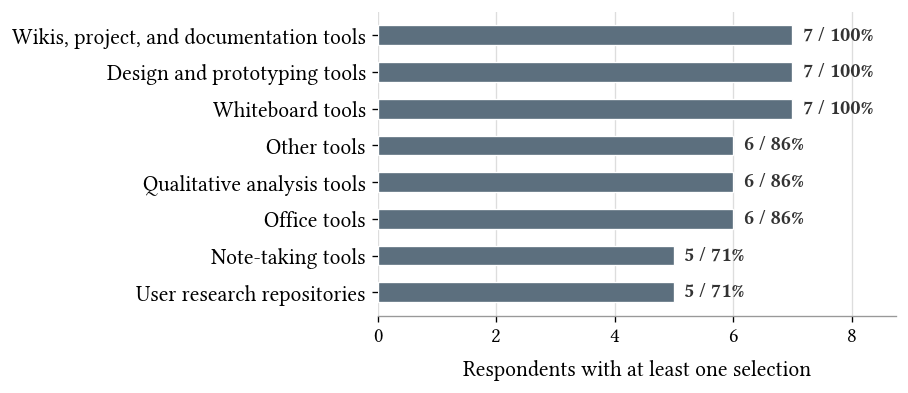

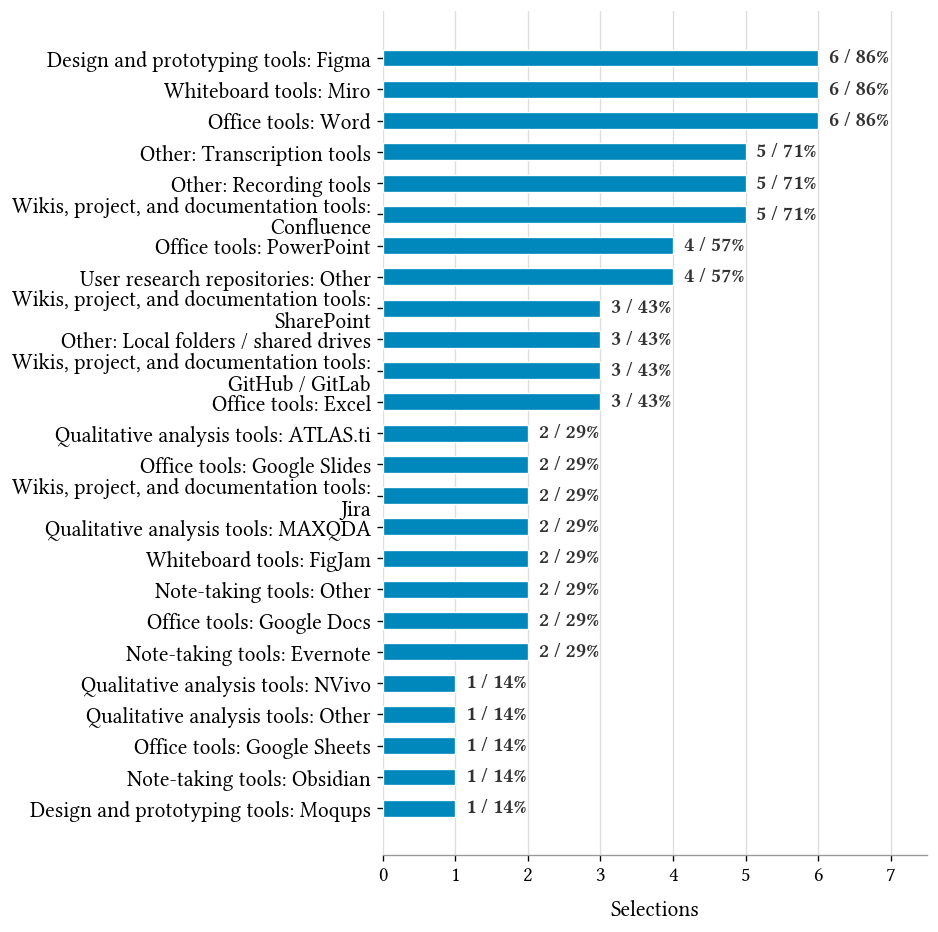

PosixPath('survey_analysis_outputs_english/figures_pdf/10_tools_specific.pdf')

In [9]:
tool_categories = {
    "B2A1": "User research repositories",
    "B2A2": "Qualitative analysis tools",
    "B2A3": "Whiteboard tools",
    "B2A4": "Design and prototyping tools",
    "B2A5": "Wikis, project, and documentation tools",
    "B2A6": "Office tools",
    "B2A7": "Note-taking tools",
    "B2A8": "Other tools",
}

tool_cols = code_cols_many(tool_categories.keys())

plot_multiselect_categories(
    analysis_df,
    tool_categories,
    None, #"Tool categories used for documentation, analysis, or reuse",
    "09_tool_categories",
)

plot_multiselect(
    analysis_df,
    tool_cols,
    None, #"Specific tools mentioned",
    "10_tools_specific",
    top_n=25,
    label_func=option_label_with_group,
)

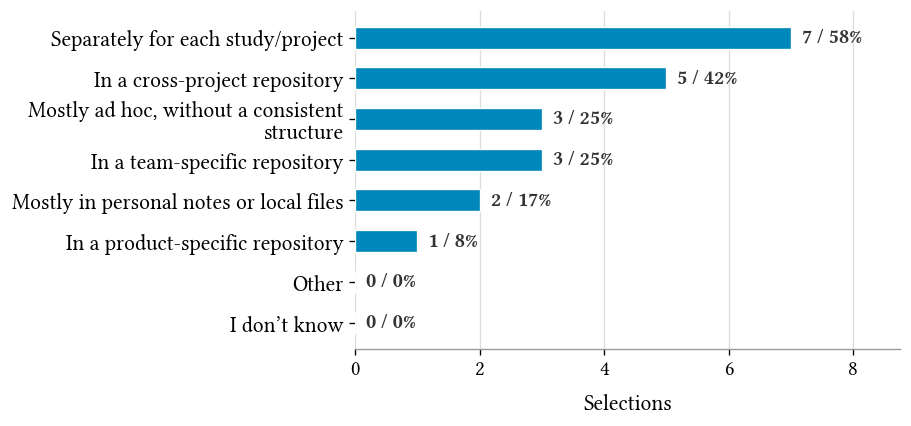

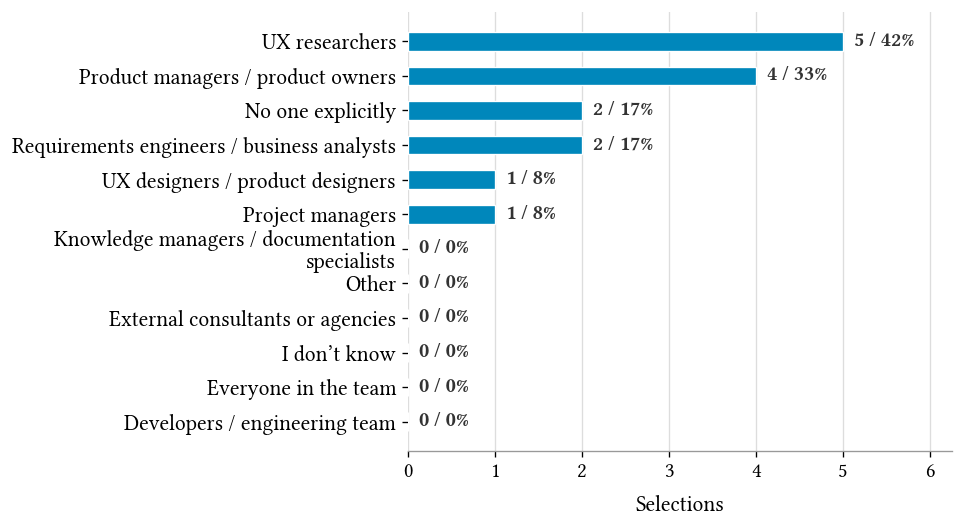

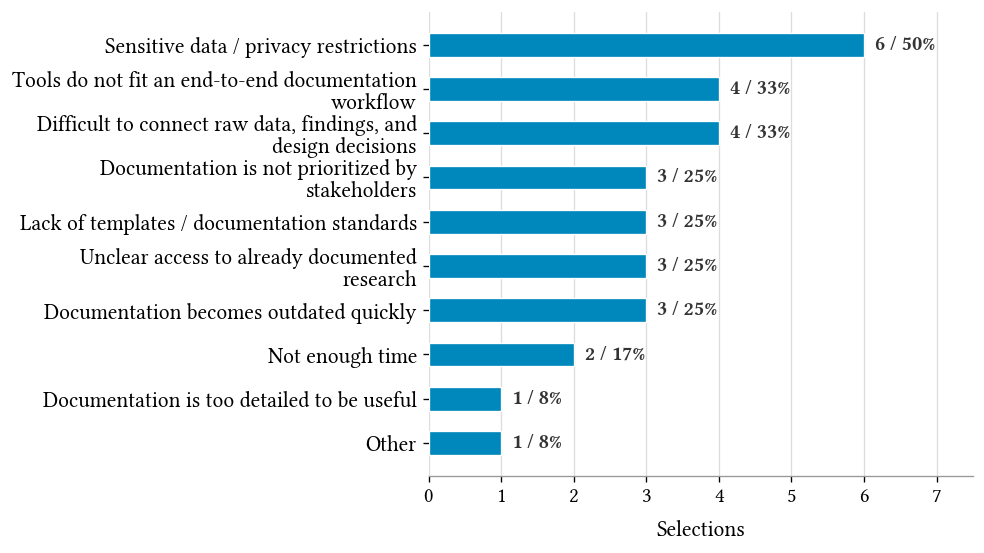

PosixPath('survey_analysis_outputs_english/figures_pdf/13_documentation_difficulties.pdf')

In [10]:
plot_multiselect(
    analysis_df,
    code_cols("B3"),
    None, #"How user research documentation is organized",
    "11_documentation_organization",
)

plot_multiselect(
    analysis_df,
    code_cols("B4"),
    None, #"Responsibility for maintaining user research documentation",
    "12_documentation_responsibility",
)

plot_multiselect(
    analysis_df,
    code_cols("B9"),
    None,#"Difficulties in user research documentation",
    "13_documentation_difficulties",
)

## 6. Traceability, documentation purposes, and reuse

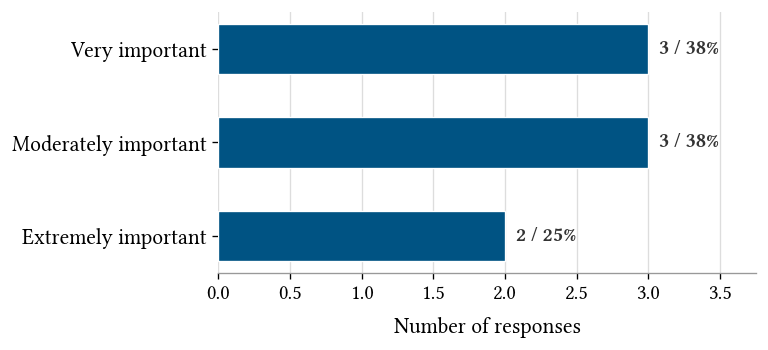

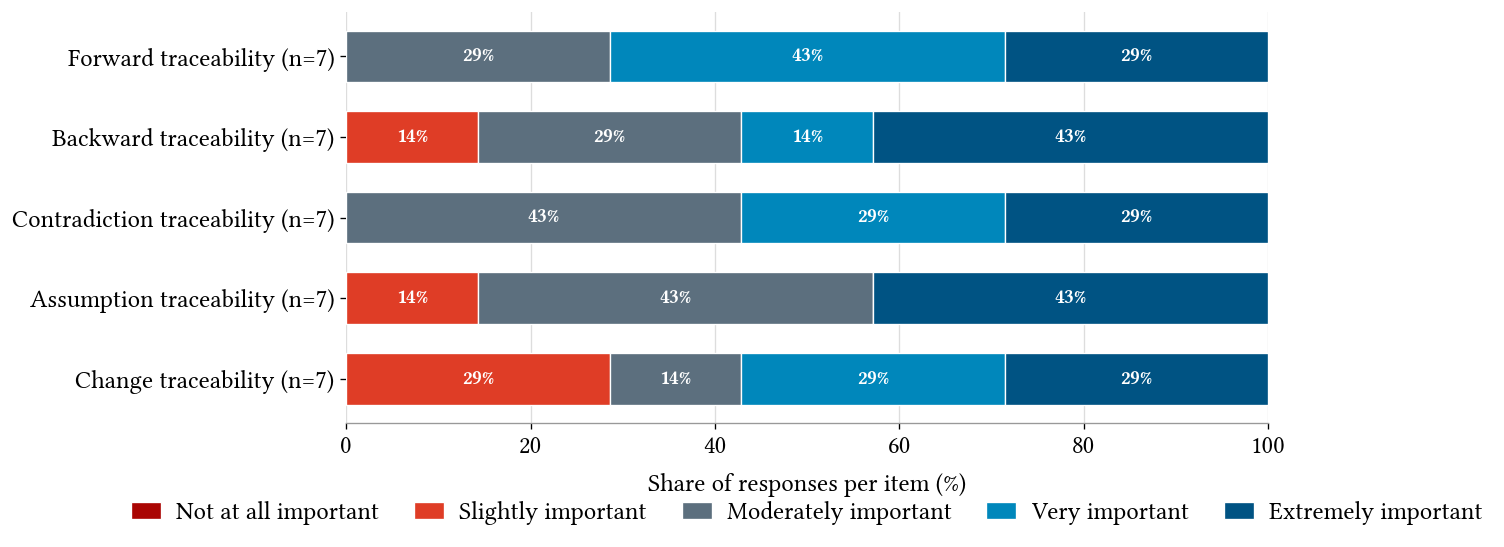

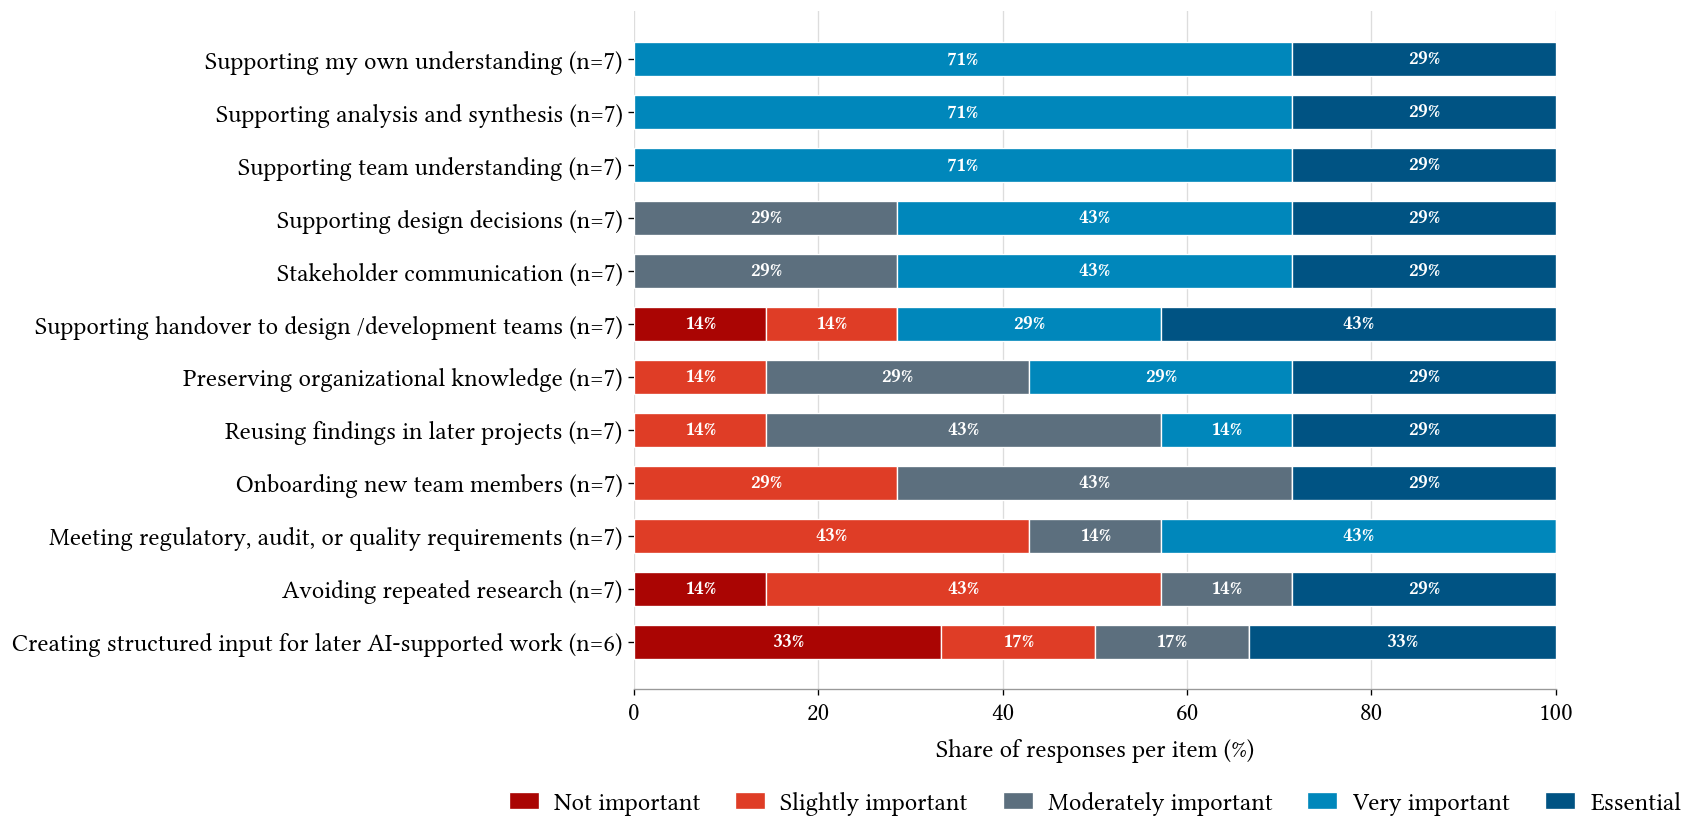

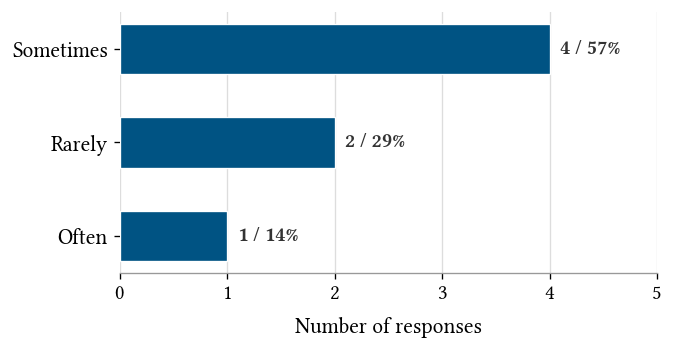

PosixPath('survey_analysis_outputs_english/figures_pdf/15b_reuse_frequency.pdf')

In [11]:
importance_order = ["Not at all important", "Slightly important", "Moderately important", "Very important", "Extremely important"]

plot_single_choice(
    analysis_df,
    single_col_by_code("B6a"),
    None, #"Overall importance of traceability",
    "14a_traceability_overall_importance",
    order=importance_order,
)

plot_likert(
    analysis_df,
    code_cols("B6b"),
    importance_order,
    None,#"Importance of different types of traceability",
    "14_traceability_importance",
)

purpose_order = ["Not important", "Slightly important", "Moderately important", "Very important", "Essential"]
purpose_cols = code_cols_many(["B7A1", "B7A2", "B7A3"])

plot_likert(
    analysis_df,
    purpose_cols,
    purpose_order,
    None,#"Purposes of documentation",
    "15_documentation_purposes",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("B8"),
    None, #"How often should documented findings be reused?",
    "15b_reuse_frequency",
    order=["Never", "Rarely", "Sometimes", "Often", "Always"],
)

## 7. AI use in research documentation

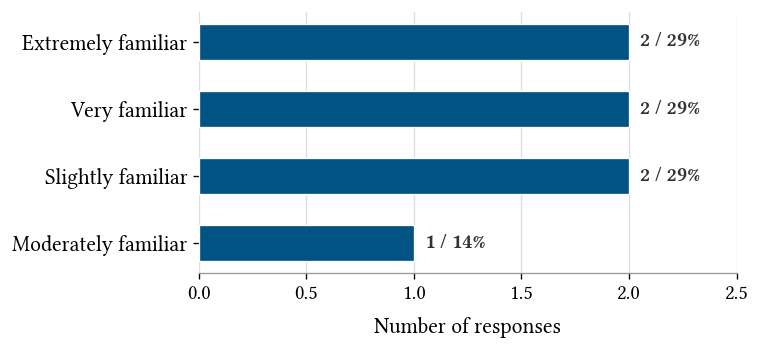

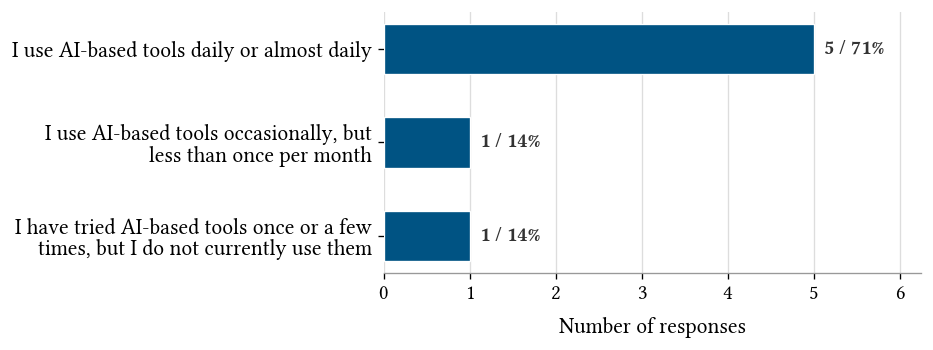

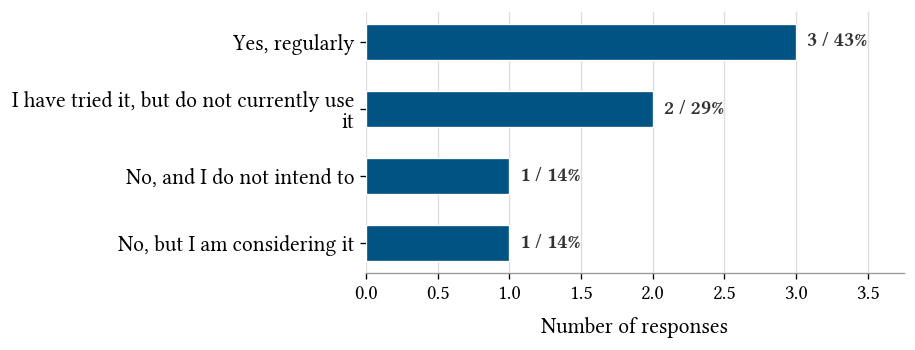

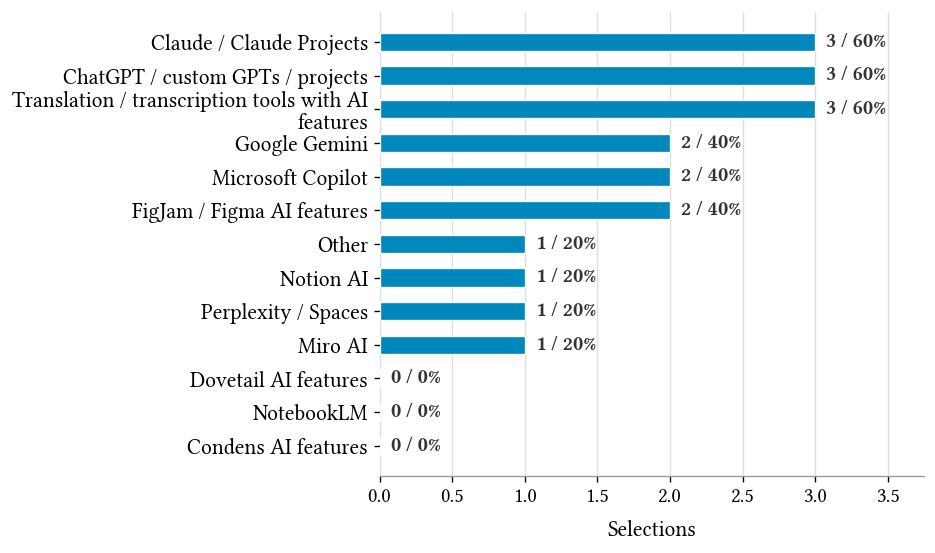

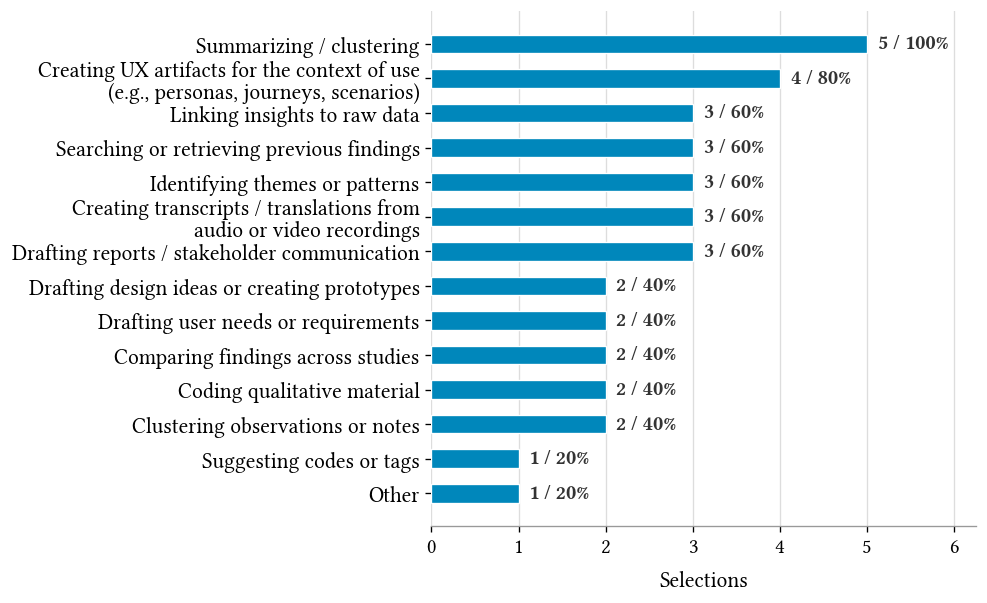

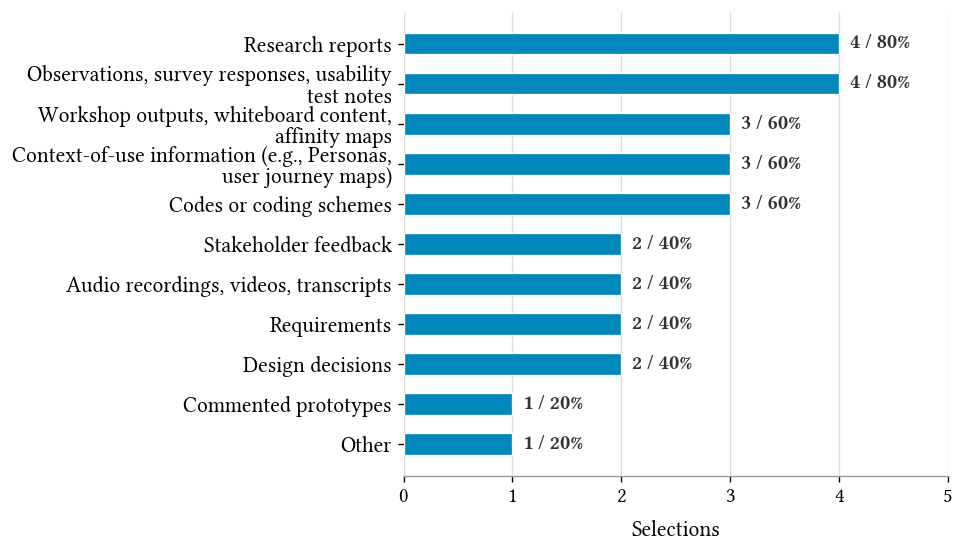

PosixPath('survey_analysis_outputs_english/figures_pdf/20_ai_input_material.pdf')

In [12]:
plot_single_choice(
    analysis_df,
    single_col_by_code("A10"),
    None, #"Familiarity with using and critically evaluating AI-based tools",
    "16a_ai_familiarity",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("A11"),
    None, #"Overall use of AI-based tools",
    "16_ai_general_use",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("C1"),
    None, #"Use of AI-based tools for user research documentation",
    "17_ai_documentation_use",
)

plot_multiselect(
    analysis_df,
    code_cols("C2"),
    None, #"AI tools or features used for user research documentation",
    "18_ai_tools",
)

plot_multiselect(
    analysis_df,
    code_cols("C3"),
    None, #"Documentation tasks supported by AI",
    "19_ai_tasks",
)

plot_multiselect(
    analysis_df,
    code_cols("C4"),
    None, #"Material provided to AI as input",
    "20_ai_input_material",
)

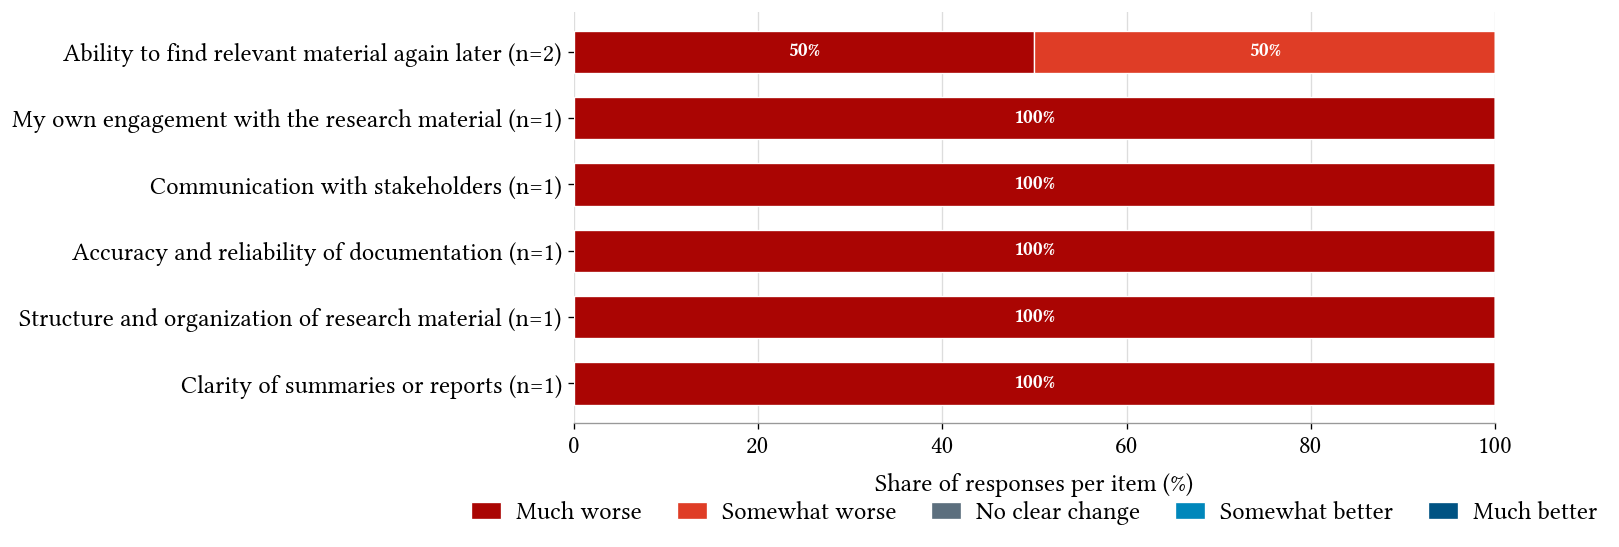

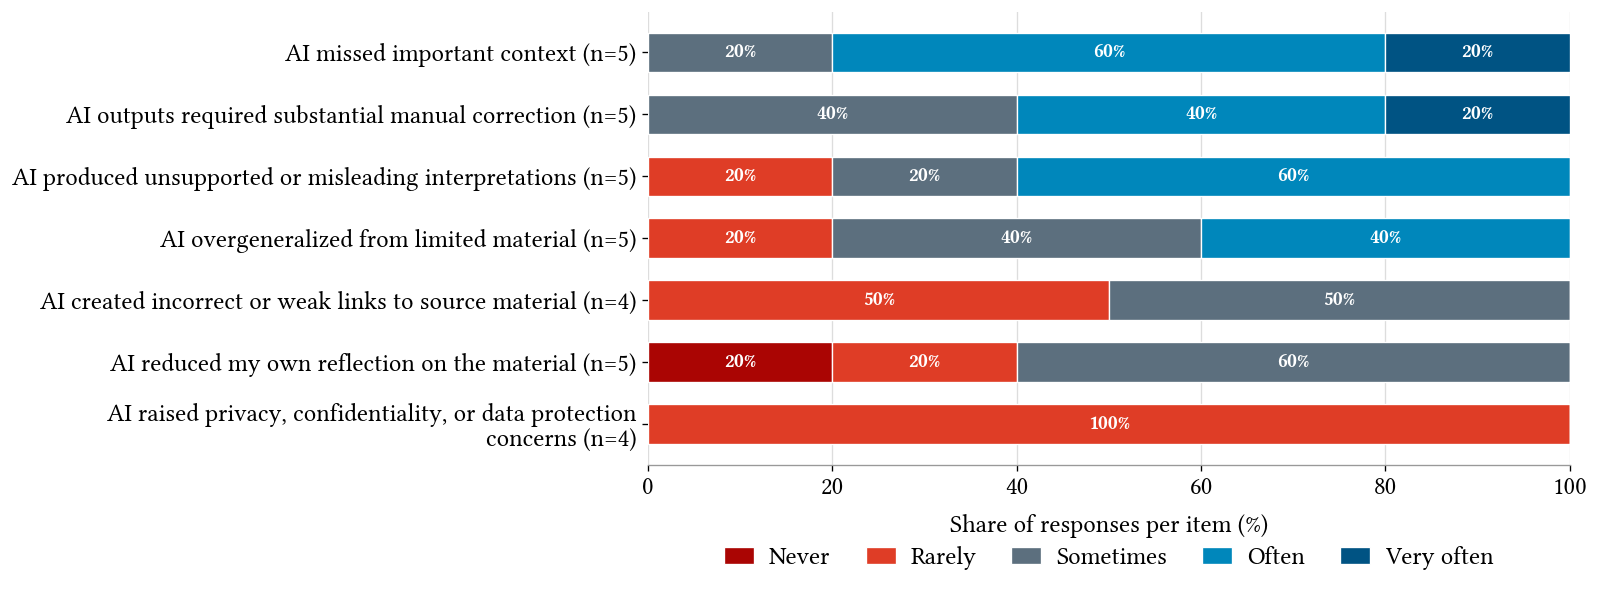

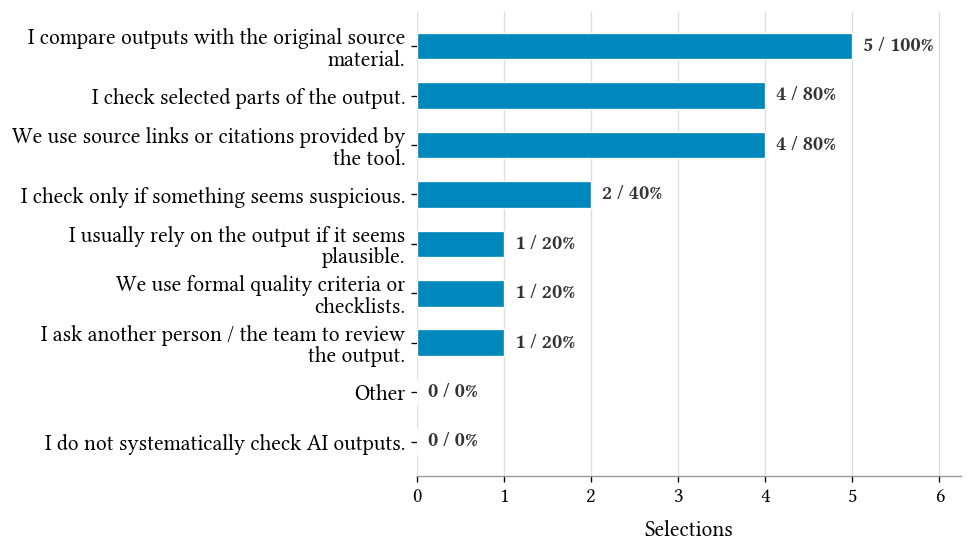

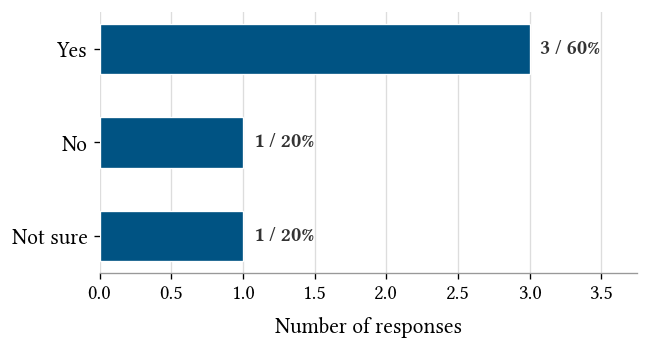

PosixPath('survey_analysis_outputs_english/figures_pdf/21c_decided_not_to_use_ai.pdf')

In [13]:
ai_effect_order = ["Much worse", "Somewhat worse", "No clear change", "Somewhat better", "Much better"]
plot_likert(
    analysis_df,
    code_cols("C5"),
    ai_effect_order,
    None,#""Perceived effects of AI support on documentation",
    "20b_ai_effects",
)

ai_problem_order = ["Never", "Rarely", "Sometimes", "Often", "Very often"]
plot_likert(
    analysis_df,
    code_cols("C6"),
    ai_problem_order,
    None,#"Problems when using AI for user research documentation",
    "21_ai_problems",
)

plot_multiselect(
    analysis_df,
    code_cols("C7"),
    "How AI-generated outputs are checked",
    "21b_ai_output_checks",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("C8"),
    "Decided not to use AI although it was technically possible",
    "21c_decided_not_to_use_ai",
)

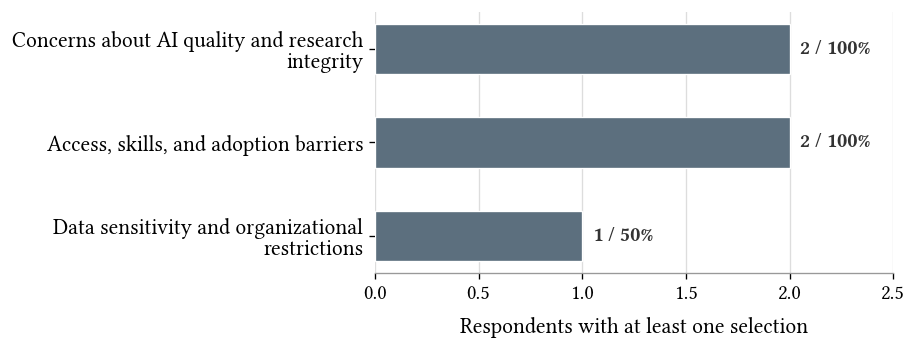

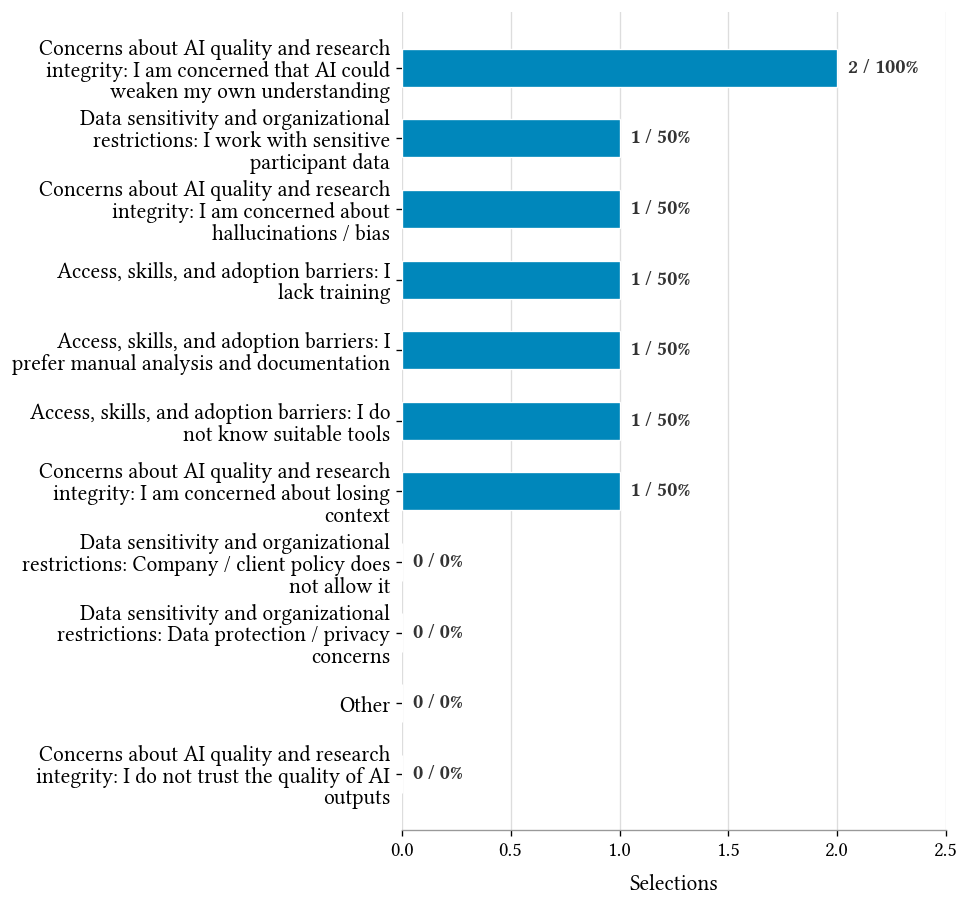

PosixPath('survey_analysis_outputs_english/figures_pdf/21e_ai_nonuse_reasons.pdf')

In [14]:
nonuse_reason_categories = {
    "C10A1": "Data sensitivity and organizational restrictions",
    "C10A2": "Access, skills, and adoption barriers",
    "C10A3": "Concerns about AI quality and research integrity",
}
nonuse_reason_cols = code_cols_many(nonuse_reason_categories.keys()) + code_cols("C10A4")

plot_multiselect_categories(
    analysis_df,
    nonuse_reason_categories,
    None, #"Reason categories for not using AI in documentation",
    "21d_ai_nonuse_reason_categories",
)

plot_multiselect(
    analysis_df,
    nonuse_reason_cols,
    None, #"Reasons for not currently using AI in documentation",
    "21e_ai_nonuse_reasons",
    label_func=option_label_with_group,
)

## 8. Future support, oversight, trust, and change over time

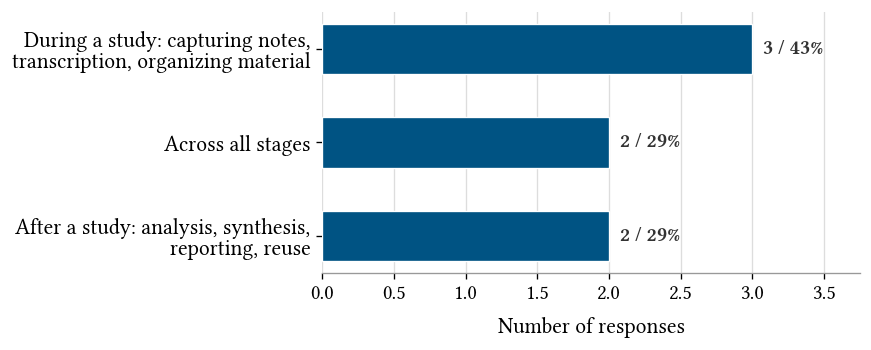

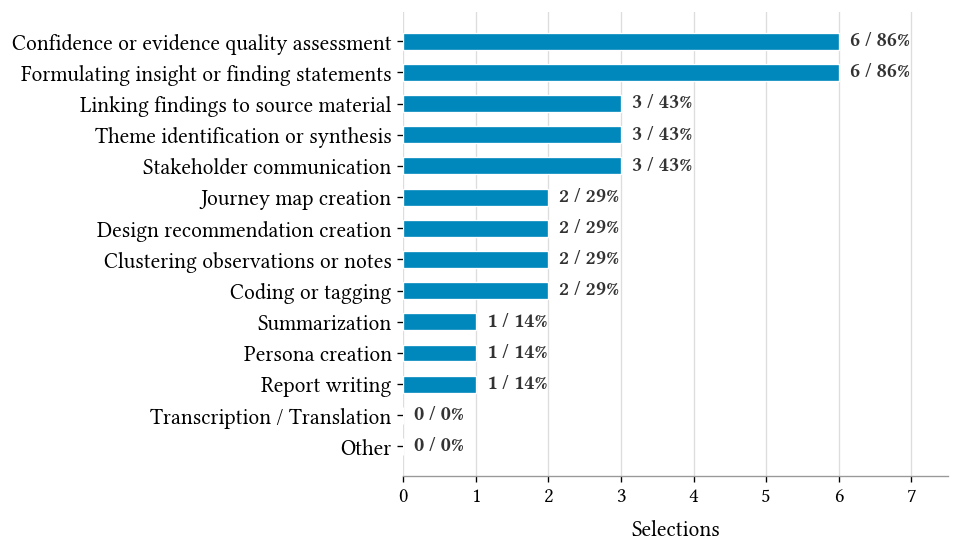

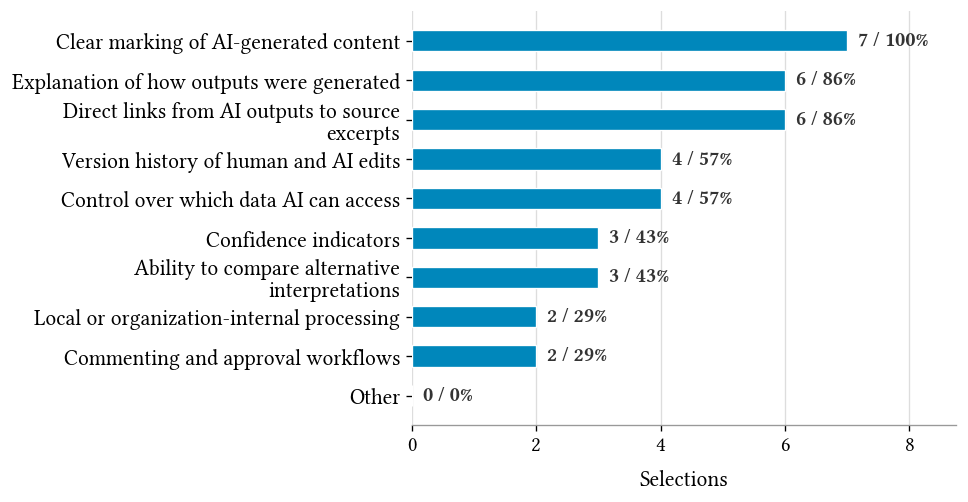

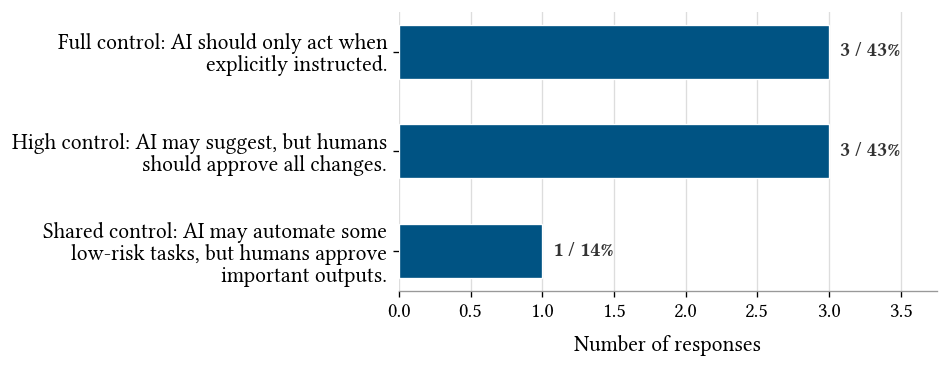

No data for G1. Compared with the time before widespread generative AI tools, has your documentation practice changed?
No selected answers for None


In [15]:
plot_single_choice(
    analysis_df,
    single_col_by_code("D2"),
    None, #"Stage where AI support would be most useful",
    "22_ai_support_stage",
)

plot_multiselect(
    analysis_df,
    code_cols("E2"),
    None, #"AI-supported tasks that require the most human oversight",
    "23_human_oversight",
)

plot_multiselect(
    analysis_df,
    code_cols("F1"),
    None, #"Features that would make AI-supported documentation more trustworthy",
    "24_trustworthy_ai_features",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("F3"),
    None, #"Desired control over AI-supported documentation",
    "25_ai_control",
)

plot_single_choice(
    analysis_df,
    single_col_by_code("G1"),
    None, #"Change in documentation practice since widespread generative AI",
    "26_documentation_practice_changed",
)

plot_multiselect(
    analysis_df,
    code_cols("G2"),
    None, #"What changed in documentation practice",
    "27_documentation_practice_changes",
)

## 9. Open answers

This cell collects free-text and comment fields in long format. 

In [16]:
meta_codes = {"id", "submitdate", "lastpage", "startlanguage", "seed", "startdate", "datestamp", "interviewtime"}
open_answer_codes = {"A7a", "B10", "C9", "C10", "D3", "E3", "H2"}
open_cols = []
for c in df.columns:
    code = column_code(c)
    low = norm(c)
    if code in meta_codes or low.startswith("question time") or low.startswith("group time") or "time." in low or "time:" in low:
        continue
    if is_comment_col(c) or is_other_text_col(c) or code in open_answer_codes:
        open_cols.append(c)

# Keep only columns with at least one non-empty answer.
open_cols = [c for c in open_cols if df[c].dropna().astype(str).str.strip().ne("").any()]

id_col = single_col_by_code("id") or first_col_contains("Response ID")
if id_col is None:
    df["_row_number"] = np.arange(1, len(df) + 1)
    id_col = "_row_number"

open_rows = []
for c in open_cols:
    for rid, txt in df[[id_col, c]].dropna().itertuples(index=False):
        txt = str(txt).strip()
        if txt:
            open_rows.append({"Response ID": rid, "question": question_label(c), "column": c, "answer": txt})
open_answers = pd.DataFrame(open_rows)
open_path = TABLE_DIR / "open_answers_long.csv"
open_answers.to_csv(open_path, index=False)
print(f"Exported {len(open_answers)} open answers to: {open_path}")

display(open_answers.head(20)) if display else print(open_answers.head(20))

Exported 53 open answers to: survey_analysis_outputs_english/tables_csv/open_answers_long.csv


,Response ID,question,column,answer
0,48,Which of the following best describes your cur...,A2[other]. Which of the following best describ...,lead position in user research in a university...
1,10,In which type of organization do you mainly work?,A3[other]. In which type of organization do yo...,Software agency
2,7,In which country do you mainly work?,A8[other]. In which country do you mainly work...,france
3,11,In which country do you mainly work?,A8[other]. In which country do you mainly work...,Bangladesh
4,45,In which country do you mainly work?,A8[other]. In which country do you mainly work...,italy
5,46,In which country do you mainly work?,A8[other]. In which country do you mainly work...,Sweden
6,5,What is your disciplinary or educational backg...,A9[other]. What is your disciplinary or educat...,computer scienc
7,3,Where does the documentation requirement come ...,A7a. Where does the documentation requirement ...,"External factors (e.g., regulations, client po..."
8,4,Where does the documentation requirement come ...,A7a. Where does the documentation requirement ...,"Internal factors (e.g., company policy)"
9,7,Where does the documentation requirement come ...,A7a. Where does the documentation requirement ...,"External factors (e.g., regulations, client po..."


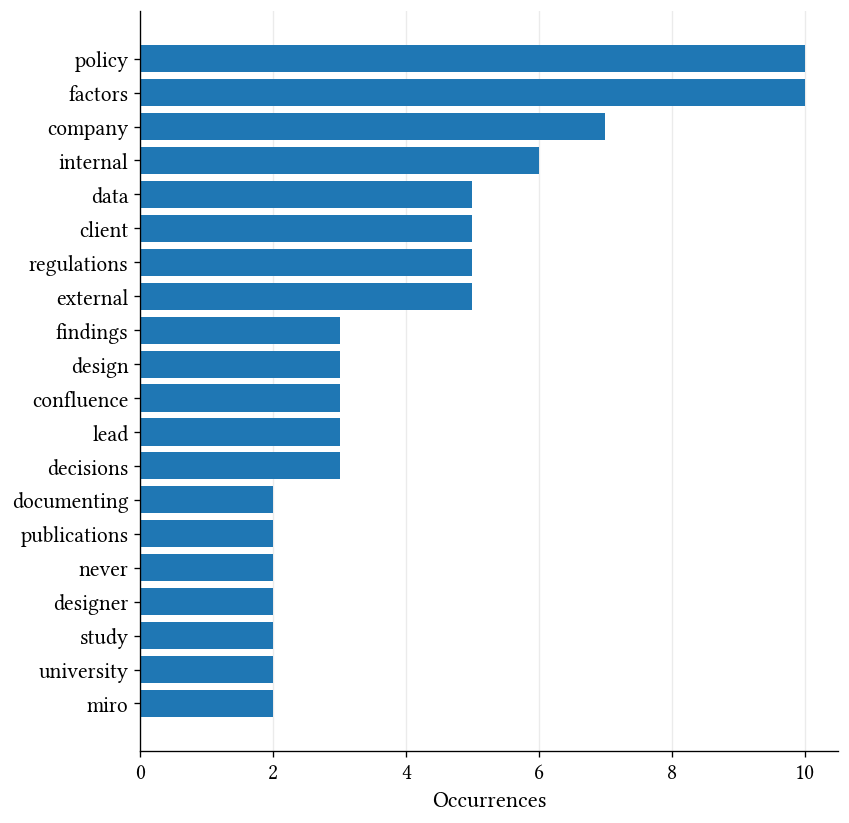

In [17]:
# Simple term-frequency overview for open answers.
# This is deliberately lightweight and should not replace qualitative coding.
if not open_answers.empty:
    stopwords = {
        "the", "and", "or", "to", "of", "in", "for", "a", "an", "is", "it", "this", "that", "with", "as", "on", "be", "are", "not",
        "we", "our", "you", "your", "from", "but", "have", "has", "was", "were", "can", "could", "would", "should", "about",
        "user", "research", "documentation", "document", "documents", "documented", "well", "only", "really","ai", "tools", "tool", "output", "outputs",
        "und", "also", "sole", "myself", "oder", "die", "der", "das", "ein", "eine", "ist", "ich", "wir", "zu", "für", "mit", "auf", "nicht", "im", "von", "den", "dem", "ki", "dokumentation",
    }
    tokens = []
    for text in open_answers["answer"].astype(str):
        tokens.extend([t.lower() for t in re.findall(r"[A-Za-zÄÖÜäöüß]{4,}", text) if t.lower() not in stopwords])
    if tokens:
        term_counts = pd.Series(tokens).value_counts().head(20).sort_values(ascending=True)
        term_counts.rename("count").to_csv(TABLE_DIR / "28_open_answers_term_frequency.csv")
        fig, ax = plt.subplots(figsize=(7.5, max(3.3, 0.34 * len(term_counts) + 1.2)))
        ax.barh(term_counts.index, term_counts.values)
        ax.set_xlabel("Occurrences")
        #ax.set_title("Common terms in open answers")
        style_axis(ax)
        save_and_show(fig, "28_open_answers_term_frequency")

## 10. Export check

In [18]:
print("PDF figures:")
pdf_files = sorted(FIG_DIR.glob("*.pdf"))
for p in pdf_files:
    print(" -", p)

print("\nCSV tables:")
csv_files = sorted(TABLE_DIR.glob("*.csv"))
for p in csv_files:
    print(" -", p)

print(f"\nExported {len(pdf_files)} PDF figures and {len(csv_files)} CSV tables.")

PDF figures:
 - survey_analysis_outputs_english/figures_pdf/01_response_status.pdf
 - survey_analysis_outputs_english/figures_pdf/02_last_page_raw.pdf
 - survey_analysis_outputs_english/figures_pdf/02b_completed_responses_per_day.pdf
 - survey_analysis_outputs_english/figures_pdf/03_roles.pdf
 - survey_analysis_outputs_english/figures_pdf/04_organization_type.pdf
 - survey_analysis_outputs_english/figures_pdf/05_experience.pdf
 - survey_analysis_outputs_english/figures_pdf/06_research_frequency.pdf
 - survey_analysis_outputs_english/figures_pdf/07_background.pdf
 - survey_analysis_outputs_english/figures_pdf/07b_documentation_required.pdf
 - survey_analysis_outputs_english/figures_pdf/08_documentation_content_frequency.pdf
 - survey_analysis_outputs_english/figures_pdf/09_tool_categories.pdf
 - survey_analysis_outputs_english/figures_pdf/10_tools_specific.pdf
 - survey_analysis_outputs_english/figures_pdf/11_documentation_organization.pdf
 - survey_analysis_outputs_english/figures_pdf/